# Variable stimulus durations with `event_durations`

This tutorial shows how to let different event classes have different stimulus durations, including durations sampled from distributions. This is useful when some events are self-paced, condition-specific, or naturally variable in length.

By the end, you will know how to:

1. define `event_durations` as a mix of fixed values and distribution specifications,
2. choose `trial_max` correctly,
3. inspect the sampled per-event durations used by a concrete design.


In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import matplotlib.pyplot as plt
import numpy as np
import neurodesign

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 110


## 1. Define duration rules per stimulus class

The base package uses one common `event_durations` for every event. `neurodesign-plus` adds `event_durations`, which lets each event code have its own rule.

Each entry in `event_durations` can be either:

- a scalar duration, or
- a dictionary describing a sampling rule such as `fixed`, `uniform`, `gaussian`, or `exponential`.

**Key parameters explained:**

- `event_durations` must have one entry per stimulus code.
- `trial_max` should be the largest possible **raw stimulus duration** across those entries.
- `trial_start_interval` and `post_event_interval` are added on top of the sampled durations when the concrete design is built.

For clarity, we keep the event order fixed in this notebook so the changing feature is the duration sampling itself.


In [2]:
fixed_order = [0, 1, 2, 3] * 5

event_durations = [
    {"model": "gaussian", "std": 0.2, "mean": 1.2, "min": 0.5, "max": 5.5},
    7.5,
    2.0,
    {"model": "uniform", "min": 3.5, "max": 4.5},
]
trial_max = 7.5

print("Stimulus-specific duration rules:")
for idx, spec in enumerate(event_durations):
    print(f"Stimulus {idx}: {spec}")
print("trial_max:", trial_max)


Stimulus-specific duration rules:
Stimulus 0: {'model': 'gaussian', 'std': 0.2, 'mean': 1.2, 'min': 0.5, 'max': 5.5}
Stimulus 1: 7.5
Stimulus 2: 2.0
Stimulus 3: {'model': 'uniform', 'min': 3.5, 'max': 4.5}
trial_max: 7.5


## 2. Build the experiment

The experiment below keeps the order fixed and lets the optimizer resample ITIs while the package independently samples event durations for each design.

That means one `Design` instance stores a concrete list of per-event durations in `realized_event_durations`, while the `Experiment` object stores only the specification.


In [3]:
exp = neurodesign.Experiment(
    TR=2,
    n_trials=len(fixed_order),
    P=[0.25, 0.25, 0.25, 0.25],
    C=[[1, 0, -1, 0], [1, 0, 0, -1], [0, 1, -1, 0], [0, 1, 0, -1]],
    n_stimuli=4,
    rho=0.3,
    trial_start_interval=1,
    post_event_interval=0.5,
    inter_trial_interval={"model": "uniform", "min": 1, "max": 4, "mean": 2.5},
    event_durations=event_durations,
    trial_max=trial_max,
    order=fixed_order,
)

population = neurodesign.Optimisation(
    experiment=exp,
    R=[1, 0, 0],
    weights=[0, 0.5, 0.25, 0.25],  # order: Fe, Fd, Ff, Fc
    preruncycles=1,
    cycles=2,
    outdes=1,
    I=1,
    G=2,
    folder="./",
    seed=100,
)

population.optimise()

C:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:1026: UserWarning: the resolution is adjusted to be a multiple of the TR. New resolution: 0.1
  warnings.warn(


Output()

Output()

First 12 event codes: [0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3]
First 12 sampled total durations (including trial_start_interval and post_event_interval):
[1.2 7.5 2.  3.9 1.3 7.5 2.  4.1 1.6 7.5 2.  3.9]
Fd (detection efficiency): 1.0000
Fe (estimation efficiency): 0.0000
Fc (confounding score): 0.2165
Ff (frequency-balance score): 1.0000


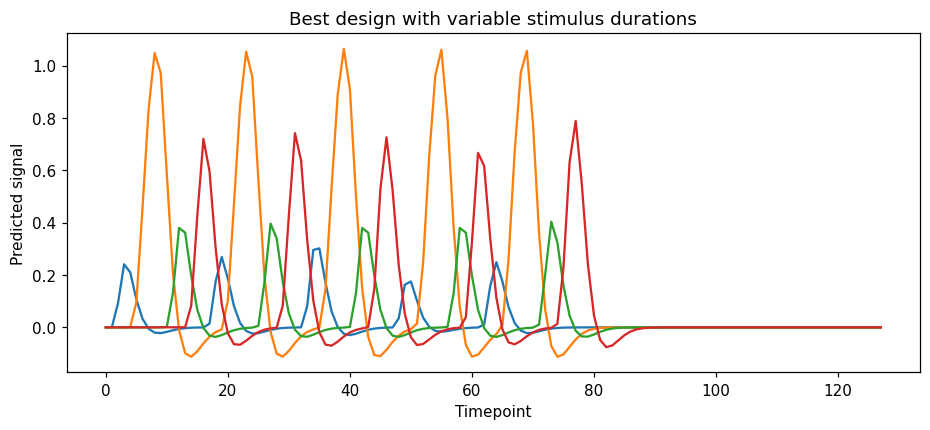

In [4]:
best_design = population.selected_design(0)
best_design.designmatrix()

print("First 12 event codes:", list(best_design.order[:12]))
print("First 12 sampled total durations (including trial_start_interval and post_event_interval):")
print(np.round(best_design.realized_event_durations[:12], 2))
print(f"Fd (detection efficiency): {best_design.Fd:.4f}")
print(f"Fe (estimation efficiency): {best_design.Fe:.4f}")
print(f"Fc (confounding score): {best_design.Fc:.4f}")
print(f"Ff (frequency-balance score): {best_design.Ff:.4f}")

fig, ax = plt.subplots()
ax.plot(best_design.Xconv)
ax.set_title("Best design with variable stimulus durations")
ax.set_xlabel("Timepoint")
ax.set_ylabel("Predicted signal")
plt.show()


## 3. Interpreting the sampled durations

Because the order is fixed, differences in peak width and spacing come from timing draws rather than from changes in event identity.

The printed `realized_event_durations` values are the concrete durations used by this particular design. They already include `trial_start_interval` and `post_event_interval`, so they are longer than the raw stimulus durations listed in `event_durations`.

As with variable ITIs, you may see trailing flat space in the full design matrix. The experiment container is built from expected maximum timing values so that every sampled design fits inside the same shared time grid.


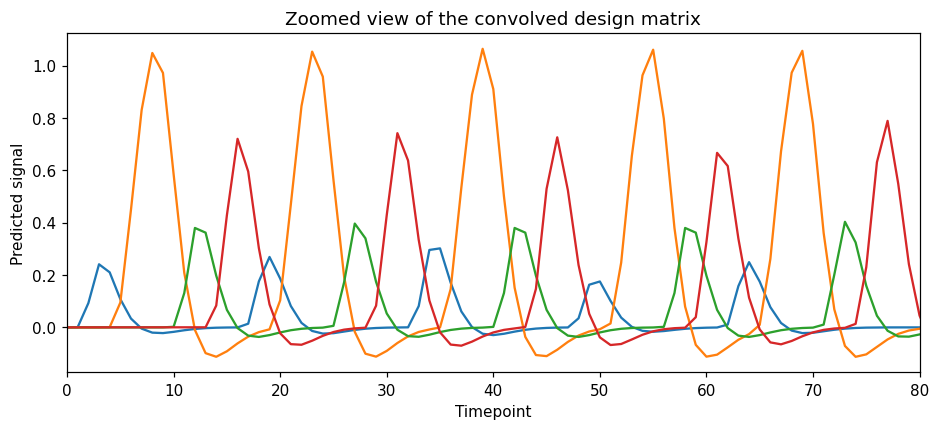

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(best_design.Xconv)
plt.xlim(0, 80)
plt.title("Zoomed view of the convolved design matrix")
plt.xlabel("Timepoint")
plt.ylabel("Predicted signal")
plt.show()


## 4. Takeaway

Use `event_durations` when event classes truly differ in duration. The main checklist is:

- provide one duration rule per stimulus code,
- set `trial_max` to the largest possible raw duration,
- remember that `trial_start_interval` and `post_event_interval` are added afterward at the event level.
